In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/test.csv', encoding='latin1')

In [4]:
df = df[['text','sentiment']]

In [5]:
df.dropna(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3534 entries, 0 to 3533
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       3534 non-null   object
 1   sentiment  3534 non-null   object
dtypes: object(2)
memory usage: 82.8+ KB


In [7]:
df['sentiment']= df['sentiment'].astype('category')

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(3534, 2)

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='count', ylabel='sentiment'>

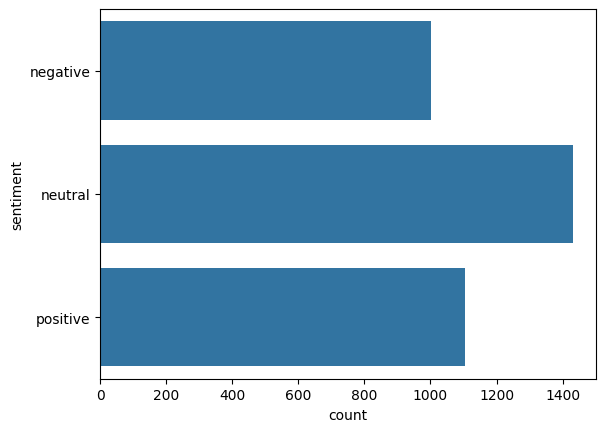

In [11]:
sns.countplot(df['sentiment'])

In [12]:
! pip install nltk

# text preprocessing

In [13]:
import nltk

In [14]:
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [15]:
from nltk.corpus import stopwords
import string

from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [16]:
[x for x in df['text']]

['Last session of the day  http://twitpic.com/67ezh',
 ' Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China:  (SH)  (BJ).',
 'Recession hit Veronique Branquinho, she has to quit her company, such a shame!',
 ' happy bday!',
 ' http://twitpic.com/4w75p - I like it!!',
 ' that`s great!! weee!! visitors!',
 'I THINK EVERYONE HATES ME ON HERE   lol',
 ' soooooo wish i could, but im in school and myspace is completely blocked',
 ' and within a short time of the last clue all of them',
 ' What did you get?  My day is alright.. haven`t done anything yet. leaving soon to my stepsister though!',
 'My bike was put on hold...should have known that.... argh total bummer',
 ' I checked.  We didn`t win',
 ' .. and you`re on twitter! Did the tavern bore you that much?',
 'I`m in VA for the weekend, my youngest son turns 2 tomorrow......it makes me kinda sad, he is getting so big, check out my twipics',
 'Its coming out the socket  I feel like my phones hole is no

In [17]:
# text Transforming
def transform(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []

  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [21]:
transform(' did you tweet me? i thought i remembered seeing one but i cant see it now! SO glad teatree is ok!')

'tweet thought rememb see one cant see glad teatre ok'

In [22]:
df['tranformed_text'] = df['text'].apply(transform)

In [83]:
filtered_transformed_texts = []
for text_string in df['tranformed_text']:
  words = text_string.split() # split the string into words
  filtered_words = [word for word in words if word != 'http' and len(word) >= 2]
  filtered_transformed_texts.append(" ".join(filtered_words))

df['tranformed_text'] = filtered_transformed_texts

In [86]:
df.drop('text',axis=1,inplace=True)

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [91]:
df
# 'negative' is encoded as 0
# 'neutral' is encoded as 1
# 'positive' is encoded as 2

,sentiment,tranformed_text
0,1,last session day
1,2,shanghai also realli excit precis skyscrap gal...
2,0,recess hit veroniqu branquinho quit compani shame
3,2,happi bday
4,2,like
...,...,...
3529,0,im tire sleep tri
3530,2,alon old hous thank net keep aliv kick whoever...
3531,0,know mean littl dog sink depress want move som...
3532,2,next youtub video gon na love video


In [94]:
df['num_character'] = df['tranformed_text'].apply(len)

In [96]:
nltk.download('punkt_tab')
# number of words
df['num_words']= df['tranformed_text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [97]:
df['num_sen'] = df['tranformed_text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [136]:
df.drop('num_sen',axis=1,inplace=True)

/tmp/ipykernel_3962/2292877897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('num_sen',axis=1,inplace=True)


In [137]:
df

,sentiment,tranformed_text,num_character,num_words
0,1,last session day,16,3
1,2,shanghai also realli excit precis skyscrap gal...,71,12
2,0,recess hit veroniqu branquinho quit compani shame,49,7
3,2,happi bday,10,2
4,2,like,4,1
...,...,...,...,...
3529,0,im tire sleep tri,17,4
3530,2,alon old hous thank net keep aliv kick whoever...,74,15
3531,0,know mean littl dog sink depress want move som...,58,10
3532,2,next youtub video gon na love video,35,7


In [160]:
df.describe()

,sentiment,num_character,num_words
count,3520.000000,3520.000000,3520.000000
mean,1.029261,36.855966,6.755966
std,0.772500,20.412526,3.640157
min,0.000000,2.000000,1.000000
25%,0.000000,21.000000,4.000000
50%,1.000000,34.000000,6.000000
75%,2.000000,52.000000,9.000000
max,2.000000,116.000000,20.000000


In [161]:
# for negative
df[df['sentiment']==0][['num_character','num_words']].describe()

,num_character,num_words
count,1000.000000,1000.000000
mean,37.997000,6.958000
std,19.858886,3.524011
min,2.000000,1.000000
25%,22.000000,4.000000
50%,36.000000,7.000000
75%,52.000000,9.000000
max,101.000000,17.000000


In [162]:
# forpositive
df[df['sentiment']==2][['num_character','num_words']].describe()

,num_character,num_words
count,1103.000000,1103.000000
mean,38.118767,6.977335
std,20.094275,3.581617
min,2.000000,1.000000
25%,23.000000,4.000000
50%,34.000000,6.000000
75%,53.000000,10.000000
max,108.000000,19.000000


In [163]:
# for neutral
df[df['sentiment']==1][['num_character','num_words']].describe()

,num_character,num_words
count,1417.000000,1417.000000
mean,35.067749,6.441073
std,20.920341,3.744236
min,2.000000,1.000000
25%,18.000000,3.000000
50%,31.000000,6.000000
75%,50.000000,9.000000
max,116.000000,20.000000


<Axes: xlabel='num_character', ylabel='Count'>

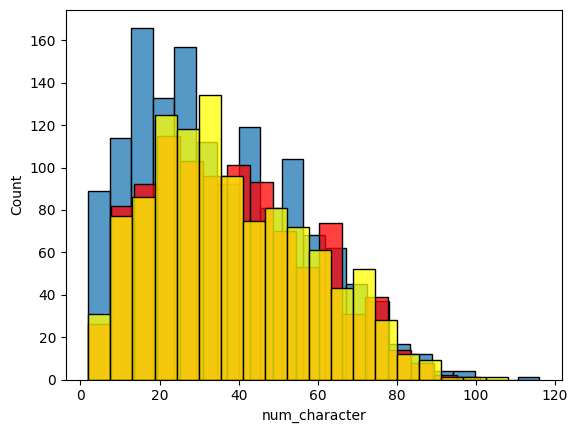

In [165]:
sns.histplot(df[df['sentiment']==1]['num_character'])
sns.histplot(df[df['sentiment']==0]['num_character'],color='red')
sns.histplot(df[df['sentiment']==2]['num_character'],color='yellow')


<Axes: xlabel='num_words', ylabel='Count'>

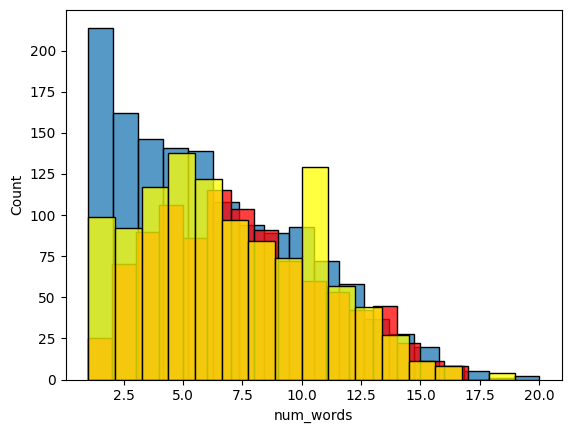

In [166]:
sns.histplot(df[df['sentiment']==1]['num_words'])
sns.histplot(df[df['sentiment']==0]['num_words'],color='red')
sns.histplot(df[df['sentiment']==2]['num_words'],color='yellow')

<Axes: xlabel='num_character', ylabel='Count'>

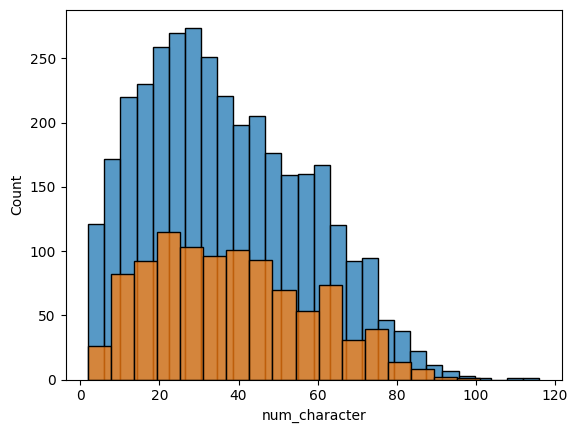

In [151]:
# for negative
sns.histplot(df['num_character'])
sns.histplot(df[df['sentiment']==0]['num_character'])


<Axes: xlabel='num_character', ylabel='Count'>

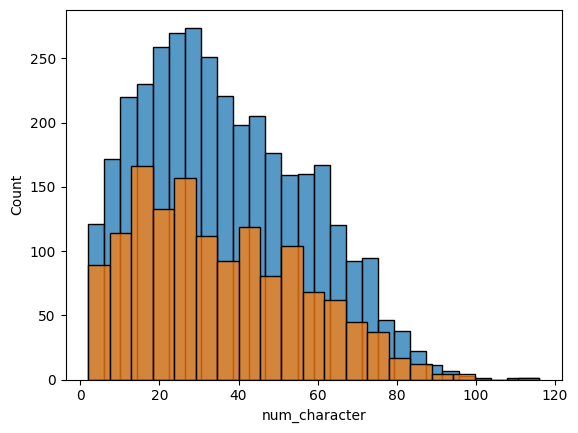

In [149]:
# for neutral
sns.histplot(df['num_character'])
sns.histplot(df[df['sentiment']==1]['num_character'])

<Axes: xlabel='num_character', ylabel='Count'>

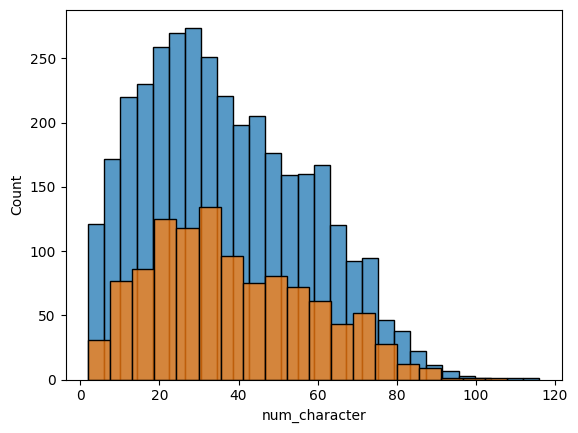

In [150]:
# positive
sns.histplot(df['num_character'])
sns.histplot(df[df['sentiment']==2]['num_character'])


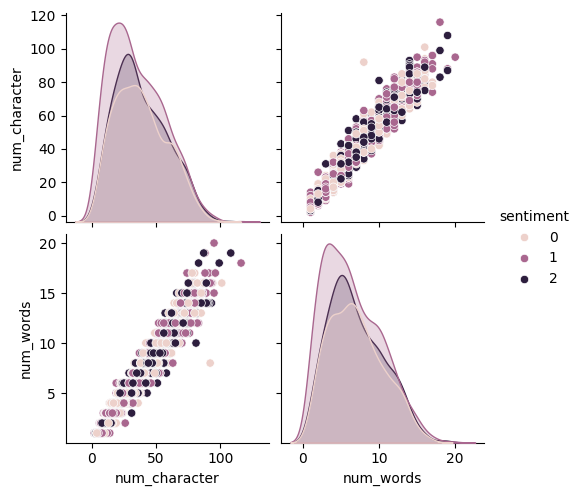

In [152]:
sns.pairplot(df,hue='sentiment')

In [153]:
from wordcloud import wordcloud

wc = wordcloud.WordCloud(width=500,height=500,min_font_size=10,background_color='white')

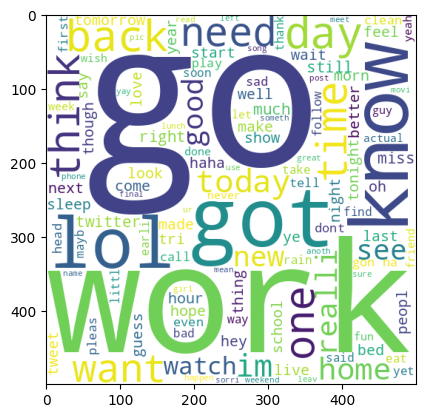

In [157]:
neutral_wc = wc.generate(df[df['sentiment']==1]['tranformed_text'].str.cat(sep=' '))
plt.imshow(neutral_wc)

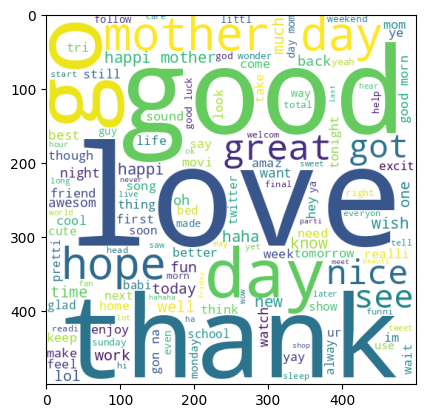

In [158]:
positive_wc = wc.generate(df[df['sentiment']==2]['tranformed_text'].str.cat(sep=' '))
plt.imshow(positive_wc)

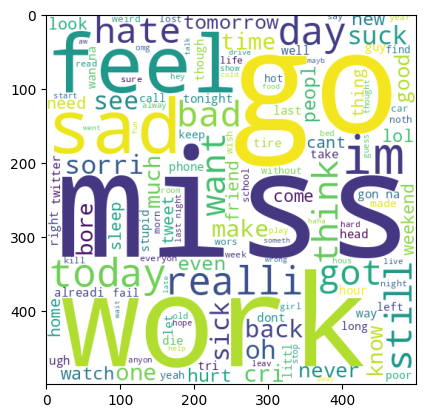

In [159]:
negative_wc = wc.generate(df[df['sentiment']==0]['tranformed_text'].str.cat(sep=' '))
plt.imshow(negative_wc)

model building

In [168]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [170]:
X = tfidf.fit_transform(df['tranformed_text']).toarray()

In [171]:
X.shape

(3520, 3000)

In [173]:
y = df['sentiment'].values

In [174]:
y.shape

(3520,)

In [175]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [179]:
df

,sentiment,tranformed_text,num_character,num_words
0,1,last session day,16,3
1,2,shanghai also realli excit precis skyscrap gal...,71,12
2,0,recess hit veroniqu branquinho quit compani shame,49,7
3,2,happi bday,10,2
4,2,like,4,1
...,...,...,...,...
3529,0,im tire sleep tri,17,4
3530,2,alon old hous thank net keep aliv kick whoever...,74,15
3531,0,know mean littl dog sink depress want move som...,58,10
3532,2,next youtub video gon na love video,35,7


In [178]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)

print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1, average='weighted'))

0.421875
[[115  47  33]
 [142  57  91]
 [ 55  39 125]]
0.42245619975930426


In [182]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2,average='weighted'))

0.6164772727272727
[[ 82 104   9]
 [ 29 213  48]
 [  7  73 139]]
0.6380743102992649


In [184]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3 , average='weighted'))

0.6122159090909091
[[ 83 104   8]
 [ 34 216  40]
 [  8  79 132]]
0.6350461380724539


In [ ]:
# tfdif --> mnb

In [185]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [186]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [187]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [190]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred, average='weighted')

    return accuracy,precision

In [191]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.6576704545454546, 0.6804003844402137)

In [192]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.6576704545454546
Precision -  0.6804003844402137
For  KN
Accuracy -  0.4474431818181818
Precision -  0.6199897864597638
For  NB
Accuracy -  0.6164772727272727
Precision -  0.6380743102992649
For  DT
Accuracy -  0.5440340909090909
Precision -  0.7197924300559271
For  LR
Accuracy -  0.6917613636363636
Precision -  0.7203570676416431
For  RF
Accuracy -  0.6832386363636364
Precision -  0.6947126357157567
For  AdaBoost
Accuracy -  0.5326704545454546
Precision -  0.7404653308384013
For  BgC
Accuracy -  0.6860795454545454
Precision -  0.6880854578644245
For  ETC
Accuracy -  0.7017045454545454
Precision -  0.7025760963620923
For  GBDT
Accuracy -  0.6761363636363636
Precision -  0.7389854941168874
For  xgb
Accuracy -  0.6903409090909091
Precision -  0.7178639069264069


In [193]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [194]:
performance_df

,Algorithm,Accuracy,Precision
6,AdaBoost,0.532670,0.740465
9,GBDT,0.676136,0.738985
4,LR,0.691761,0.720357
3,DT,0.544034,0.719792
10,xgb,0.690341,0.717864
8,ETC,0.701705,0.702576
5,RF,0.683239,0.694713
7,BgC,0.686080,0.688085
0,SVC,0.657670,0.680400
2,NB,0.616477,0.638074


In [195]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,AdaBoost,Accuracy,0.532670
1,GBDT,Accuracy,0.676136
2,LR,Accuracy,0.691761
3,DT,Accuracy,0.544034
4,xgb,Accuracy,0.690341
5,ETC,Accuracy,0.701705
6,RF,Accuracy,0.683239
7,BgC,Accuracy,0.686080
8,SVC,Accuracy,0.657670
9,NB,Accuracy,0.616477


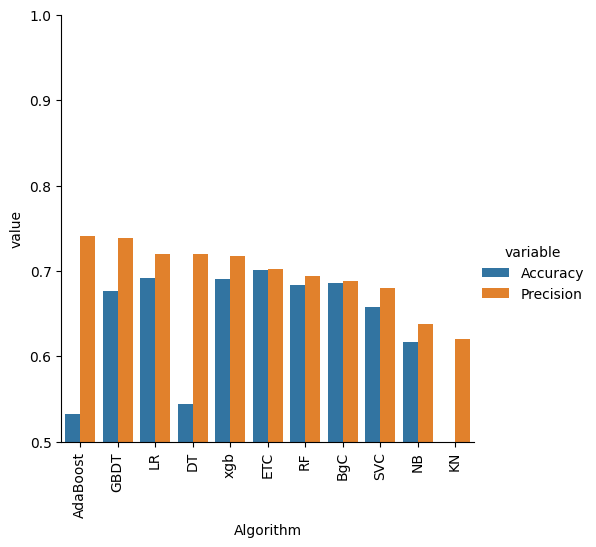

In [196]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [203]:
# Voting Classifier
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
bc = BaggingClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [205]:
voting = VotingClassifier(estimators=[('et', etc),('lr',lrc),('bc',bc)],voting='soft')
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2)),
                             ('lr',
                              LogisticRegression(penalty='l1',
                                                 solver='liblinear')),
                             ('bc',
                              BaggingClassifier(n_estimators=50,
                                                random_state=2))],
                 voting='soft')

In [206]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred, average='weighted'))

Accuracy 0.703125
Precision 0.7093363578577345


In [207]:
# Applying stacking
estimators=[('et', etc),('lr',lrc),('bc',bc)]
final_estimator=RandomForestClassifier()
from sklearn.ensemble import StackingClassifier

In [208]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred , average='weighted'))

Accuracy 0.6846590909090909
Precision 0.687590706680811


In [211]:
from collections import Counter
Counter(y)

Counter({np.int64(1): 1417, np.int64(2): 1103, np.int64(0): 1000})

In [213]:
from imblearn.over_sampling import SMOTE
Balancer = SMOTE(random_state = 42)
X_final, y_final = Balancer.fit_resample(X, y)

In [214]:
Counter(y_final)

Counter({np.int64(1): 1417, np.int64(2): 1417, np.int64(0): 1417})

In [215]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X_final, y_final, test_size=0.2, random_state=2)

etc_final = ExtraTreesClassifier(n_estimators=50, random_state=2)
etc_final.fit(X_train_final, y_train_final)
y_pred_final = etc_final.predict(X_test_final)

print("Accuracy for ExtraTreesClassifier on balanced data:", accuracy_score(y_test_final, y_pred_final))
print("Precision for ExtraTreesClassifier on balanced data:", precision_score(y_test_final, y_pred_final, average='weighted'))

Accuracy for ExtraTreesClassifier on balanced data: 0.7426556991774383
Precision for ExtraTreesClassifier on balanced data: 0.7416686354637264


In [216]:
lrc_final = LogisticRegression(solver='liblinear', penalty='l1')
lrc_final.fit(X_train_final, y_train_final)
y_pred_lrc_final = lrc_final.predict(X_test_final)

print("Accuracy for Logistic Regression on balanced data:", accuracy_score(y_test_final, y_pred_lrc_final))
print("Precision for Logistic Regression on balanced data:", precision_score(y_test_final, y_pred_lrc_final, average='weighted'))

Accuracy for Logistic Regression on balanced data: 0.6980023501762632
Precision for Logistic Regression on balanced data: 0.7131940096998487


In [226]:
import nltk
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer() # Initialize stemmer

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib # For saving the pipeline
import pandas as pd # For DataFrame/Series operations
from sklearn.ensemble import ExtraTreesClassifier # Import the classifier
from sklearn.preprocessing import LabelEncoder # Needed for consistent label encoding

# Redefine the TextPreprocessor class to include all custom text cleaning steps
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.ps = PorterStemmer()
        self.stopwords = set(stopwords.words('english'))
        self.punctuation = set(string.punctuation)

    def _transform_single_text(self, text):
        text = str(text).lower() # Convert to string and lowercase
        tokens = nltk.word_tokenize(text)

        # Keep alphanumeric words
        processed_tokens = [token for token in tokens if token.isalnum()]

        # Remove stopwords and punctuation
        processed_tokens = [token for token in processed_tokens if token not in self.stopwords and token not in self.punctuation]

        # Apply stemming
        stemmed_tokens = [self.ps.stem(token) for token in processed_tokens]

        # Apply additional filtering (remove 'http' and words less than 2 characters)
        filtered_tokens = [word for word in stemmed_tokens if word != 'http' and len(word) >= 2]

        return " ".join(filtered_tokens)

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        # X is expected to be a Series or list of text strings
        return pd.Series(X).apply(self._transform_single_text)

# Reload the original DataFrame to get the 'text' column and its corresponding 'sentiment'
original_raw_df = pd.read_csv('/content/test.csv', encoding='latin1')
# Filter and preprocess as done in earlier cells to get correct labels
original_raw_df.dropna(subset=['sentiment', 'text'], inplace=True) # Ensure no NaNs in target columns

# Ensure sentiment is consistently encoded as before
le = LabelEncoder()
# Fit LabelEncoder with all possible sentiment labels to ensure consistent mapping
# Based on previous execution, sentiments are 'negative', 'neutral', 'positive'
le.fit(['negative', 'neutral', 'positive'])
y_labels = le.transform(original_raw_df['sentiment'])

# Initialize TF-IDF Vectorizer with the same parameters used previously
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

# Initialize the ExtraTreesClassifier with the parameters that performed well
etc_classifier = ExtraTreesClassifier(n_estimators=50, random_state=2)

# Create the full model pipeline
model_pipeline = Pipeline([
    ('text_preprocessing', TextPreprocessor()),
    ('tfidf_vectorization', tfidf_vectorizer),
    ('classifier', etc_classifier)
])

# Fit the complete model pipeline on the raw text data and its corresponding labels
model_pipeline.fit(original_raw_df['text'], y_labels)

# Export the fitted model pipeline
joblib.dump(model_pipeline, 'sentiment_model_pipeline.pkl')

print("Full sentiment model pipeline (TextPreprocessor + TF-IDF + ExtraTreesClassifier) created and exported as 'sentiment_model_pipeline.pkl'.")
print("This pipeline can now be used to make predictions on new raw text data.")
print("Example usage after loading:")
print("  # loaded_model_pipeline = joblib.load('sentiment_model_pipeline.pkl')")
print("  # new_text = ['This is a great movie!', 'I am feeling terrible today.']")
print("  # predictions = loaded_model_pipeline.predict(new_text)")
print("  # predicted_sentiments = le.inverse_transform(predictions) # Use the same LabelEncoder to convert back")


Full sentiment model pipeline (TextPreprocessor + TF-IDF + ExtraTreesClassifier) created and exported as 'sentiment_model_pipeline.pkl'.
This pipeline can now be used to make predictions on new raw text data.
Example usage after loading:
  # loaded_model_pipeline = joblib.load('sentiment_model_pipeline.pkl')
  # new_text = ['This is a great movie!', 'I am feeling terrible today.']
  # predictions = loaded_model_pipeline.predict(new_text)
  # predicted_sentiments = le.inverse_transform(predictions) # Use the same LabelEncoder to convert back


In [ ]:
import gradio as gr
import joblib
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the full sentiment model pipeline
# This pipeline includes TextPreprocessor, TfidfVectorizer, and ExtraTreesClassifier
model_pipeline = joblib.load('sentiment_model_pipeline.pkl')

# Define the LabelEncoder and fit it with all possible sentiment labels
# This ensures consistency when mapping predicted numerical labels back to text
le = LabelEncoder()
# Fit LabelEncoder using the full set of unique sentiment labels ('negative', 'neutral', 'positive')
le.fit(['negative', 'neutral', 'positive'])

def predict_sentiment(text):
    # The loaded pipeline directly takes raw text and outputs a numerical prediction
    prediction = model_pipeline.predict([text])

    # Convert numerical prediction back to original sentiment label
    sentiment_label = le.inverse_transform(prediction)

    return sentiment_label[0]

# Create Gradio interface
interface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Enter text here..."),
    outputs=gr.Textbox(),
    title="Sentiment Analysis App (ExtraTreesClassifier)",
    description="Enter text to predict its sentiment (negative, neutral, or positive) using the ExtraTreesClassifier model."
)

# Launch the interface
interface.launch(debug=True, share=True)
